# Phase 2: Quality Control & Batch Correction
QC filtering, log-normalization, HVG selection, PCA and Harmony integration across patients.

### Cell 1: Imports & Paths

In [1]:
import os
import warnings
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ad.settings.allow_write_nullable_strings = True  # needed to save .h5ad with pandas 2.x
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=80, facecolor="white")

BASE_DIR = os.getcwd()
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
print("Scanpy version:", sc.__version__)

Scanpy version: 1.12.4


### Cell 2: Load Raw Data & Compute QC Metrics

AnnData object with n_obs × n_vars = 197954 × 33694
    obs: 'sample_id', 'gsm_id', 'patient_id', 'tissue_type'
    layers: None (.X)


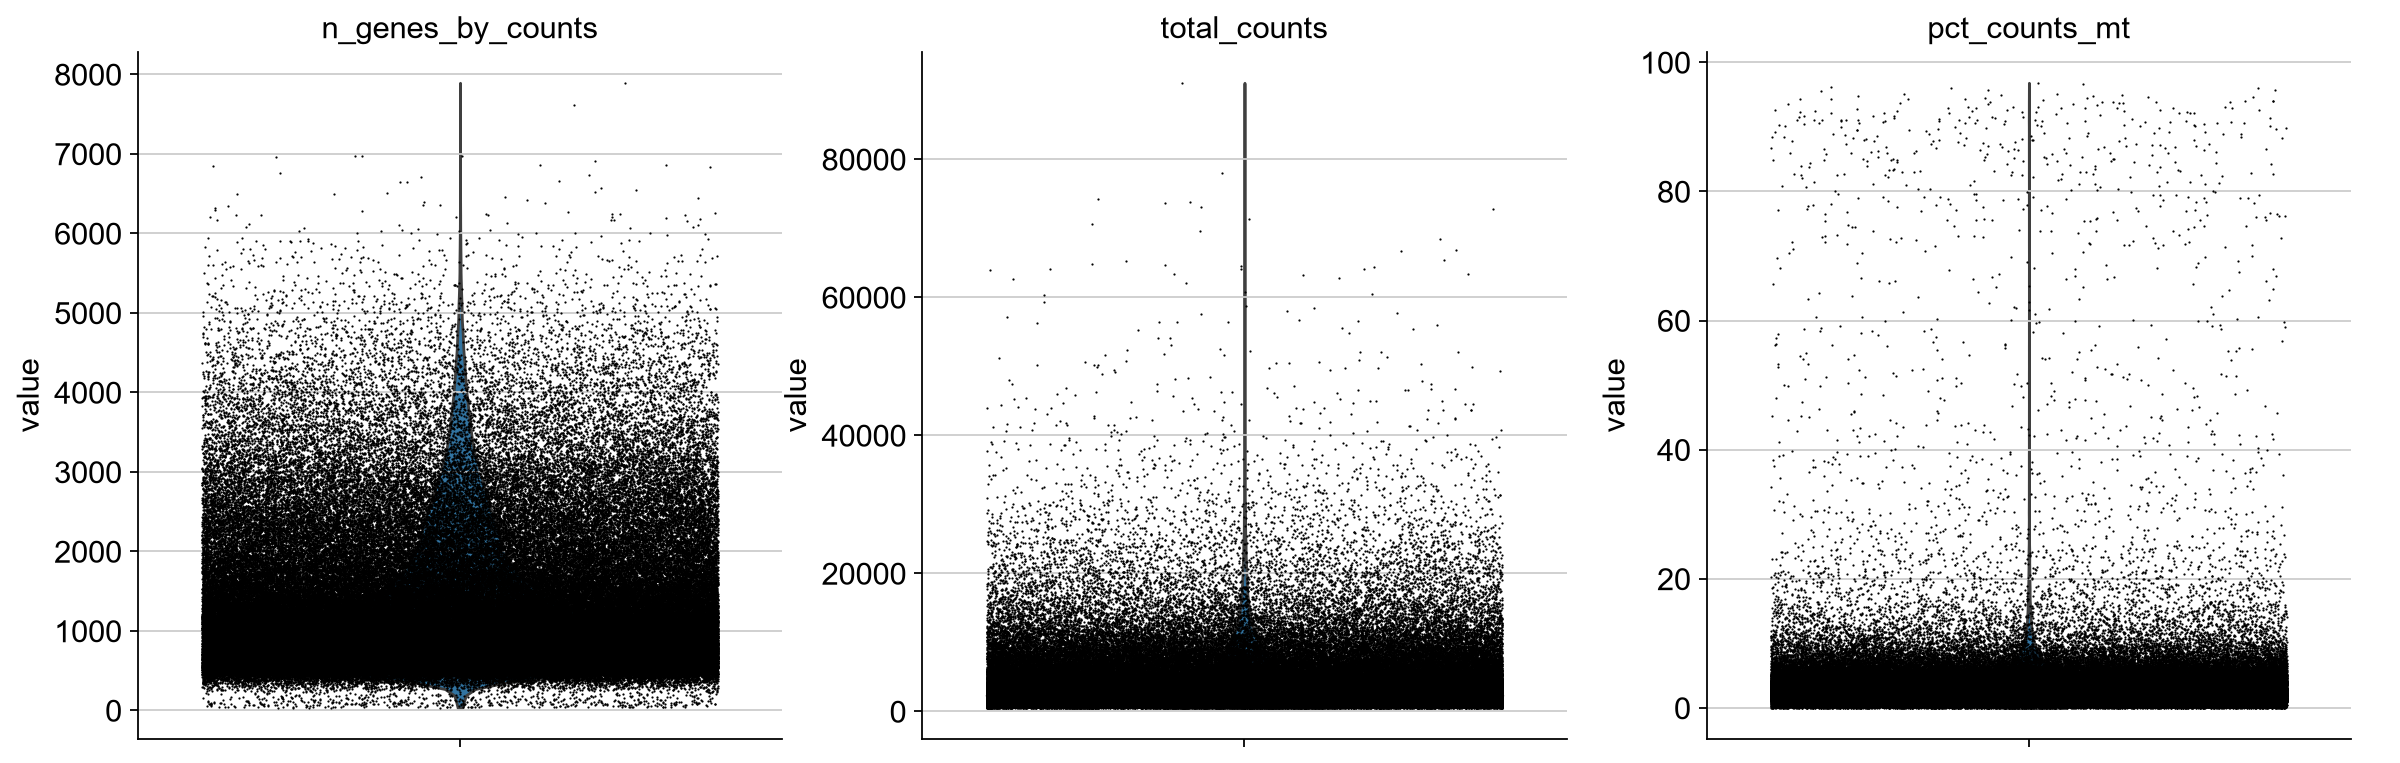

In [2]:
input_path = os.path.join(PROCESSED_DIR, "adata_raw_master.h5ad")
adata = sc.read_h5ad(input_path)

# float32 halves memory for ~198k cells without affecting results
adata.X = adata.X.astype(np.float32)
print(adata)

# Flag mitochondrial genes and compute QC metrics
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

### Cell 3: Cell & Gene Filtering

In [3]:
initial_cells = adata.n_obs

# Filter damaged cells and doublets
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=7500)
sc.pp.filter_genes(adata, min_cells=3)

# Remove high mitochondrial content cells (>15%)
adata = adata[adata.obs["pct_counts_mt"] < 15.0, :].copy()

filtered_cells = adata.n_obs
print("\n--- FILTERING COMPLETE ---")
print(f"Remaining high-quality cells: {filtered_cells} (Removed {initial_cells - filtered_cells} cells)")

filtered out 520 cells that have less than 200 genes expressed


filtered out 2 cells that have more than 7500 genes expressed


filtered out 6869 genes that are detected in less than 3 cells



--- FILTERING COMPLETE ---
Remaining high-quality cells: 195352 (Removed 2602 cells)


### Cell 4: Log Normalization & HVG Selection

normalizing counts per cell


    finished (0:00:07)


extracting highly variable genes


    finished (0:00:11)


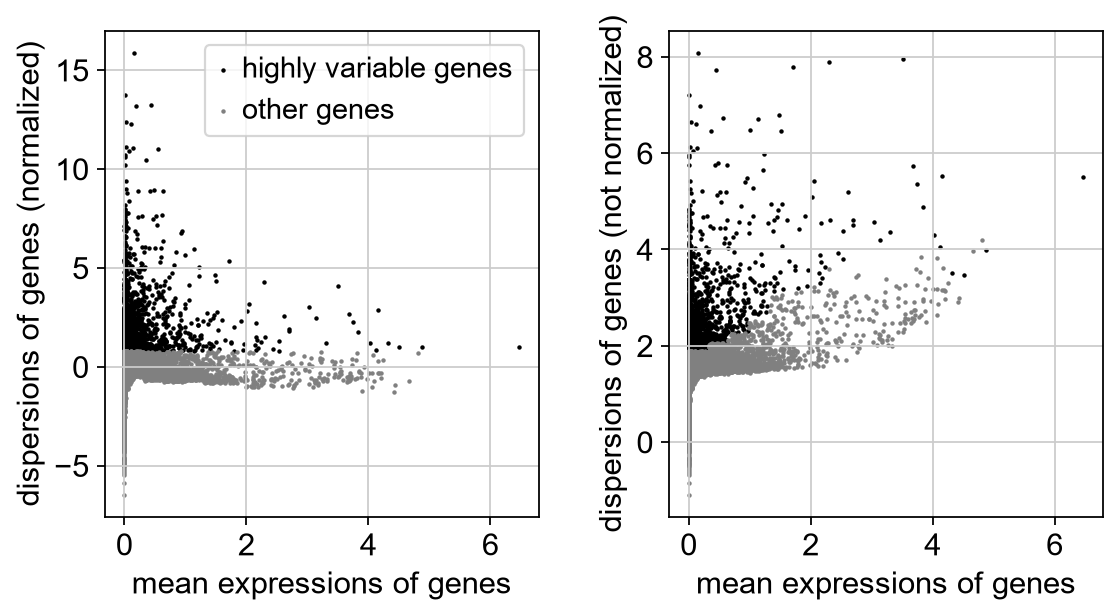

In [4]:
# Keep raw counts layer (.copy() so in-place normalization doesn't overwrite it)
adata.raw = adata.copy()

# Total count normalization to 10k reads/cell + Log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Extract top 3,000 Highly Variable Genes (HVGs)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    subset=False,
    flavor="seurat"
)

sc.pl.highly_variable_genes(adata)

**NOTE — Breakdown of Results**

- **Violin QC plots:** `n_genes_by_counts` centres around 1,500–3,500 detected genes. Dots above 7,500 are potential doublets; dots below 200 are empty droplets. Cell 3's filter (`min_genes=200`, `max_genes=7500`) removes these outliers.
- **`pct_counts_mt`:** Most cells sit below 10% mitochondrial expression. The sparse tail up to 100% marks dead/dying cells; truncating at 15% removes them.
- **HVG plot:** Dispersion vs. mean expression separates black dots (top 3,000 HVGs used downstream) from grey dots (stable housekeeping genes).

### Cell 5: Dimensionality Reduction (PCA) & Harmony Batch Integration

In [5]:
# Isolate HVG matrix for PCA & Harmony
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver="arpack", n_comps=50)

# Run Harmony to align patients while keeping tumor biology
print("Running Harmony batch correction across patients...")
sc.external.pp.harmony_integrate(adata_hvg, key="patient_id", basis="X_pca", adjusted_basis="X_pca_harmony")

# Copy representations back to main AnnData
adata.obsm["X_pca_harmony"] = adata_hvg.obsm["X_pca_harmony"]
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]
del adata_hvg

# Save processed dataset
output_qc_path = os.path.join(PROCESSED_DIR, "adata_processed_qc.h5ad")
print(f"\nSaving preprocessed dataset to {output_qc_path}...")
adata.write_h5ad(output_qc_path, compression="gzip")
print("Phase 2 Complete!")

computing PCA


    with n_comps=50


    finished (0:02:12)


Running Harmony batch correction across patients...


2026-09-27 20:57:33,768 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


...

2026-09-27 21:00:22,398 - harmonypy - INFO - Iteration 2 of 10


2026-09-27 21:03:19,383 - harmonypy - INFO - Iteration 3 of 10


2026-09-27 21:06:15,484 - harmonypy - INFO - Converged after 3 iterations



Saving preprocessed dataset to C:\Users\omar_\OneDrive\Pictures\Documents\Project codes\thyroid_scRNA\processed_data\adata_processed_qc.h5ad...


Phase 2 Complete!
